<a href="https://colab.research.google.com/github/PSG72-cmd/Stroke-Prediction/blob/main/02_visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stroke Prediction Dataset: Visualizations
Charts made from the **cleaned** dataset. Each chart has a short insight below it.

## Setup: load the cleaned data

In [1]:
import pandas as pd              # tables
import matplotlib.pyplot as plt  # charts
import seaborn as sns            # nicer charts
import os                        # for making folders

sns.set_style("whitegrid")
os.makedirs("plots", exist_ok=True)   # folder where charts are saved

url = "https://raw.githubusercontent.com/PSG72-cmd/Stroke-Prediction/main/stroke_cleaned.csv"  # link to the cleaned csv on GitHub

try:
    df = pd.read_csv(url)        # read cleaned data from GitHub
except Exception:
    from google.colab import files
    print("GitHub link failed. Please upload stroke_cleaned.csv")
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

print(df.shape)
df.head()

GitHub link failed. Please upload stroke_cleaned.csv


Saving stroke_cleaned.csv to stroke_cleaned.csv
(5109, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,169.365,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,169.365,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.920,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,169.365,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,169.365,24.0,never smoked,1


## Plot 1: How many people had a stroke?
A count plot shows how many rows are in each group.

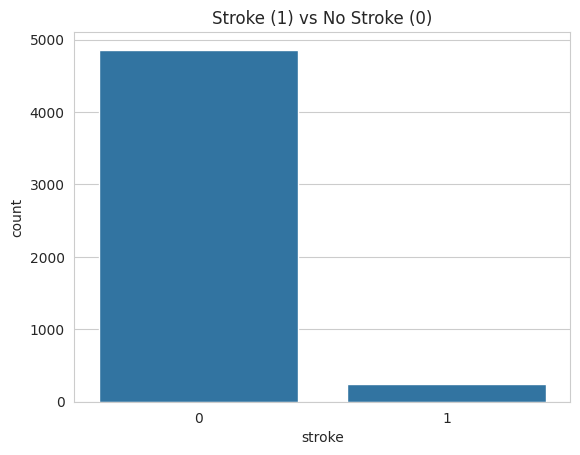

stroke
0    0.951
1    0.049
Name: proportion, dtype: float64


In [2]:
sns.countplot(x="stroke", data=df)           # bars for stroke 0 and 1
plt.title("Stroke (1) vs No Stroke (0)")
plt.savefig("plots/1_stroke_count.png", bbox_inches="tight")   # save as image
plt.show()
print(df["stroke"].value_counts(normalize=True).round(3))      # share of each group

**Insight:** Only a small share of people had a stroke, so the data is imbalanced.

## Plot 2: Age distribution
A histogram shows how ages are spread.

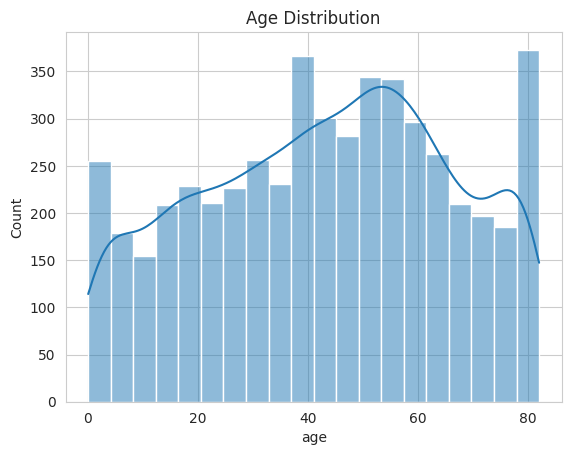

In [3]:
sns.histplot(df["age"], bins=20, kde=True)   # bars of age groups plus a smooth line
plt.title("Age Distribution")
plt.savefig("plots/2_age_hist.png", bbox_inches="tight")
plt.show()

**Insight:** Write what you see: which age range has the most people?

## Plot 3: Age vs stroke
A box plot compares the age of people with and without stroke.

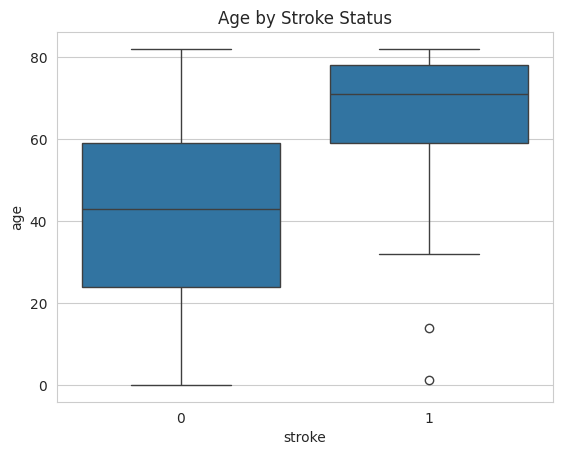

stroke
0    43.0
1    71.0
Name: age, dtype: float64


In [4]:
sns.boxplot(x="stroke", y="age", data=df)
plt.title("Age by Stroke Status")
plt.savefig("plots/3_age_stroke.png", bbox_inches="tight")
plt.show()
print(df.groupby("stroke")["age"].median())   # median age of each group

**Insight:** Compare the two medians printed above. Which group is older?

## Plot 4: Glucose level vs stroke

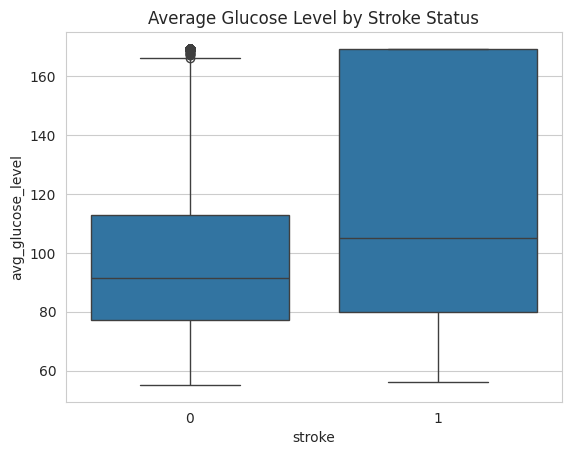

stroke
0     91.465
1    105.220
Name: avg_glucose_level, dtype: float64


In [5]:
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.title("Average Glucose Level by Stroke Status")
plt.savefig("plots/4_glucose_stroke.png", bbox_inches="tight")
plt.show()
print(df.groupby("stroke")["avg_glucose_level"].median())

**Insight:** Compare the medians. Is glucose higher in the stroke group?

## Plot 5: Hypertension and stroke rate
The bar height is the share of people who had a stroke.

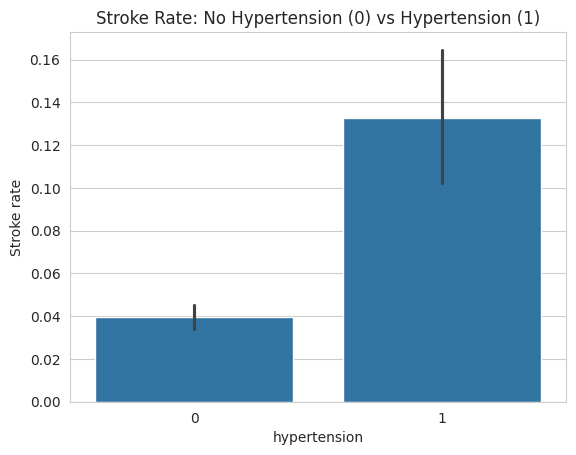

In [6]:
sns.barplot(x="hypertension", y="stroke", data=df)   # average of stroke = stroke rate
plt.title("Stroke Rate: No Hypertension (0) vs Hypertension (1)")
plt.ylabel("Stroke rate")
plt.savefig("plots/5_hypertension.png", bbox_inches="tight")
plt.show()

**Insight:** Which bar is taller, and by how much?

## Plot 6: Smoking status and stroke

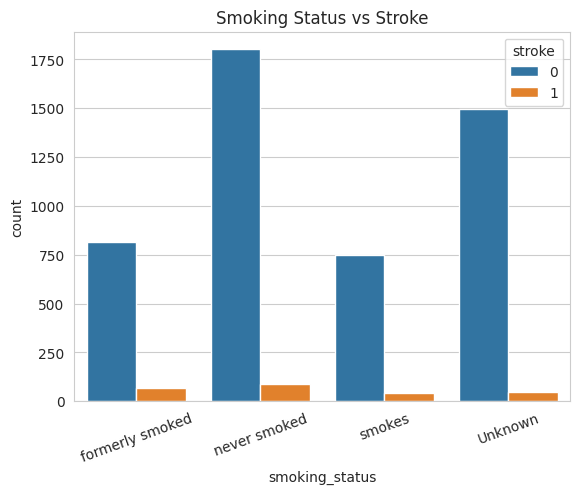

In [7]:
sns.countplot(x="smoking_status", hue="stroke", data=df)   # bars split by stroke
plt.title("Smoking Status vs Stroke")
plt.xticks(rotation=20)
plt.savefig("plots/6_smoking.png", bbox_inches="tight")
plt.show()

**Insight:** Note that 'Unknown' is a large group, so be careful about conclusions.

## Plot 7 (bonus): Correlation heatmap
Shows how strongly number columns move together (closer to 1 = stronger).

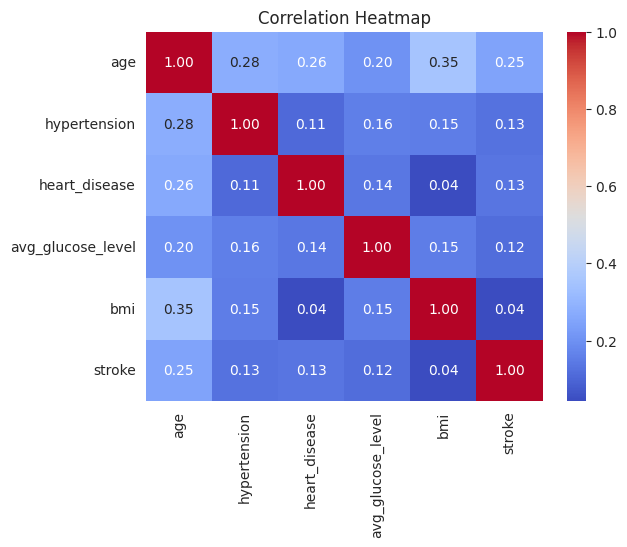

In [8]:
num_df = df.select_dtypes(include="number")   # keep only number columns
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("plots/7_heatmap.png", bbox_inches="tight")
plt.show()

**Insight:** Which column has the strongest link with `stroke`?

## Download all plots

In [9]:
try:
    !zip -r plots.zip plots
    from google.colab import files
    files.download("plots.zip")
except Exception:
    print("Plots saved in the plots/ folder")

  adding: plots/ (stored 0%)
  adding: plots/4_glucose_stroke.png (deflated 16%)
  adding: plots/5_hypertension.png (deflated 19%)
  adding: plots/7_heatmap.png (deflated 9%)
  adding: plots/2_age_hist.png (deflated 9%)
  adding: plots/6_smoking.png (deflated 16%)
  adding: plots/1_stroke_count.png (deflated 21%)
  adding: plots/3_age_stroke.png (deflated 19%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>